# 01 — Training experiments

## Fruit detection with YOLO11

**Purpose:** Train a YOLO11 model to detect apples in orchard images.

---

# Section 0 - Environment & dependencies

## Libraries

In [1]:
# Install / verify dependencies
!pip install ultralytics supervision --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.6/273.6 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 11.1 MB/s eta 0:00:00


In [2]:
import ultralytics

ultralytics.checks()    # prints GPU info, verifies CUDA

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [3]:
# This cell is safe to re-run; pip will skip already-installed packages.
#import subprocess, sys

#subprocess.run([
#    sys.executable,
#    "-m",
#    "pip",
#    "install",
#    "ultralytics>=8.3",
#    "supervision>=0.21",
#    "--quiet"])

In [4]:
import os, shutil, random, json, yaml, math
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

from IPython.display import display, Image as IPImage

from ultralytics import YOLO
import torch

import datetime

## Environment detection

In [5]:
PLATFORM = "Colab"

if PLATFORM == "Colab":
    ROOT_IN = Path("/content/project_fruit_detection/")
    ROOT_OUT = Path("/content/working/")
elif PLATFORM == "Kaggle":
    ROOT_IN = Path("/kaggle/input/datasets/matarauj/project-fruit-detection/")
    ROOT_OUT = Path("/kaggle/working/")
else:
    ROOT_IN = Path(".").resolve()
    ROOT_OUT = Path(".").resolve()

In [6]:
import sys

print(f"Environment: {PLATFORM}")
print(f"Python     : {sys.version.split()[0]}")
print(f"PyTorch    : {torch.__version__}")
print(f"CUDA       : {torch.cuda.is_available()}  —  {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

Environment: Colab
Python     : 3.12.13
PyTorch    : 2.11.0+cu128
CUDA       : True  —  Tesla T4


# Section 1 - Configuration

All training hyperparameters live here. Adjust before each run — no need to hunt through later cells.

| Parameter    | Colab (experiment) | Kaggle (full run) |
|-----------   |------------------- |-------------------|
| `epochs`     | 30 - 50            | 100               |
| `model_size` | `n` (nano)         | `m` (medium)      |
| `batch`      | 8 - 16             | 16 - 32           |

In [7]:
CFG = {
    # ── Dataset ───────────────────────────────────────────────────────────────
    "kaggle_dataset"  : "matarauj/project-fruit-detection",
    "num_classes"     : 1,
    "class_names"     : ["apple"],
    "val_ratio"       : 0.15,
    "test_ratio"      : 0.10,
    "split_seed"      : 42,

    # ── Model ────────────────────────────────────────────────────────────────
    # Sizes: n (nano) → s → m → l → x (extra-large)
    "model_size"      : "n",

    # ── Training ─────────────────────────────────────────────────────────────
    "epochs"          : 50,
    "batch"           : 16,          # Reduce to 8 if you hit GPU OOM
    "imgsz"           : 640,
    "patience"        : 10,          # Early stopping patience
    "lr0"             : 0.01,        # Initial learning rate
    "lrf"             : 0.01,        # Final LR as a fraction of lr0 (cosine schedule)
    "warmup_epochs"   : 3,
    "optimizer"       : "SGD",       # SGD or AdamW
    "weight_decay"    : 0.0005,

    # ── Augmentation ─────────────────────────────────────────────────────────
    "mosaic"          : 1.0,         # Mosaic 4-image composition
    "mixup"           : 0.1,         # MixUp blending
    "fliplr"          : 0.5,         # Horizontal flip probability
    "flipud"          : 0.0,
    "hsv_h"           : 0.015,       # Hue shift
    "hsv_s"           : 0.7,         # Saturation shift
    "hsv_v"           : 0.4,         # Brightness / value shift
    "degrees"         : 5.0,         # Rotation ±degrees
    "translate"       : 0.1,
    "scale"           : 0.5,

    # ── Output ───────────────────────────────────────────────────────────────
    "project"         : "runs",
    "run_name"        : "fruit_v1",
    "save_period"     : 10,          # Save checkpoint every N epochs
    "workers"         : 2,           # DataLoader workers (Colab: 2; Kaggle: 4)
    "seed"            : 42,
    "verbose"         : True
}

print("Configuration loaded:")

for k, v in CFG.items():
    print(f"  {k:<20} {v}")

Configuration loaded:
  kaggle_dataset       matarauj/project-fruit-detection
  num_classes          1
  class_names          ['apple']
  val_ratio            0.15
  test_ratio           0.1
  split_seed           42
  model_size           n
  epochs               50
  batch                16
  imgsz                640
  patience             10
  lr0                  0.01
  lrf                  0.01
  warmup_epochs        3
  optimizer            SGD
  weight_decay         0.0005
  mosaic               1.0
  mixup                0.1
  fliplr               0.5
  flipud               0.0
  hsv_h                0.015
  hsv_s                0.7
  hsv_v                0.4
  degrees              5.0
  translate            0.1
  scale                0.5
  project              runs
  run_name             fruit_v1
  save_period          10
  workers              2
  seed                 42
  verbose              True


# Section 2 - Dataset access

## Mount dataset

### Colab


The "kaggle.json" file is copied from Google Drive. Then, the dataset is downloaded to the workspace. Finally, the data is extracted from the ZIP file.

In [8]:
from google.colab import drive
import os

In [9]:
!kaggle --version

Kaggle CLI 2.0.2


In [10]:
drive.mount("/content/drive")

Mounted at /content/drive


In [11]:
!mkdir ~/.kaggle

In [12]:
!cp '/content/drive/MyDrive/Work/Kaggle_Colab_API/kaggle_colab.json' ~/.kaggle/kaggle.json

In [13]:
!chmod 600 ~/.kaggle/kaggle.json

In [14]:
!kaggle datasets download matarauj/project-fruit-detection

Dataset URL: https://www.kaggle.com/datasets/matarauj/project-fruit-detection
License(s): unknown
100% 232M/232M [00:14<00:00, 16.5MB/s]



In [15]:
# Input
#data_root = "/content/project_fruit_detection"
os.makedirs(ROOT_IN, exist_ok=True)

# Output
#os.makedirs('/content/working', exist_ok=True)
os.makedirs(ROOT_OUT, exist_ok=True)

In [16]:
!unzip -q project-fruit-detection.zip -d {ROOT_IN}

### Kaggle

(-)

---

## File organisation - input data (`RAW_DATASET_DIR`)

**`RAW_DATASET_DIR`** holds everything that came from Kaggle — videos, frames, labels, and split manifests. It is never written to during training; only read from.

```
RAW_DATASET_DIR/
└── data/
    ├── raw/         original .mp4 videos
    ├── processed/   extracted .jpg frames (all of them, regardless of split)
    ├── labels/       YOLO .txt label files  ← renamed from "annotations"
    └── splits/
        ├── dataset.yaml
        ├── train.txt   (list of image paths — not a folder)
        ├── val.txt
        └── test.txt
```

In [17]:
####################
# INPUT
####################
DATA_DIR            = ROOT_IN / "data"
RAW_DIR             = DATA_DIR / "raw"
PROCESSED_DIR       = DATA_DIR / "processed"
LABELS_DIR          = DATA_DIR / "labels"
SPLITS_DIR          = DATA_DIR / "splits"

DATASET_YAML = SPLITS_DIR / "dataset.yaml"

In [18]:
assert DATASET_YAML.exists(), f'Not found: {DATASET_YAML}'

In [19]:
RAW_DATASET_DIR = ROOT_IN   # Folder for input data
WORK_DIR = ROOT_OUT         # Folder for saving and exporting intermediate and final results

## Patch `dataset.yaml` for the current environment

`dataset.yaml` uses **manifest-based** splits (`train.txt`/`val.txt`/`test.txt`), not physical `train/`, `val/`, `test/` folders — no images are duplicated on disk. The `path:` field inside it needs to match wherever `RAW_DATASET_DIR` happens to be this session (Colab vs Kaggle have different mount points), so we patch it in memory rather than hardcoding it in the file.

In [20]:
with open(DATASET_YAML, "r") as f:
    dataset_cfg = yaml.safe_load(f)

# Point at this session's DATA_DIR — works identically on Colab or Kaggle
dataset_cfg["path"]  = str(DATA_DIR)
dataset_cfg["train"] = "splits/train.txt"
dataset_cfg["val"]   = "splits/val.txt"
dataset_cfg["test"]  = "splits/test.txt"

# Write the patched version to WORK_DIR so RAW_DATASET_DIR stays read-only
PATCHED_DATASET_YAML = WORK_DIR / "dataset.yaml"
with open(PATCHED_DATASET_YAML, "w") as f:
    yaml.dump(dataset_cfg, f, default_flow_style=False, sort_keys=False)

print(f"Patched dataset.yaml written to: {PATCHED_DATASET_YAML}")
print()
print(open(PATCHED_DATASET_YAML).read())

Patched dataset.yaml written to: /content/working/dataset.yaml

path: /content/project_fruit_detection/data
train: splits/train.txt
val: splits/val.txt
test: splits/test.txt
nc: 1
names:
  0: apple



## Section 3 - Dataset inspection

### Verification cell

In [21]:
# Quick check: do manifests resolve to real image+label pairs?
for split_name in ("train", "val", "test"):
    manifest = SPLITS_DIR / f"{split_name}.txt"
    paths = [p.strip() for p in manifest.read_text().splitlines() if p.strip()]

    missing_img, missing_lbl = [], []
    for p in paths:
        img_path = Path(p)
        if not img_path.is_absolute():
            img_path = DATA_DIR / p
        if not img_path.exists():
            missing_img.append(img_path)

        # Mirror Ultralytics' own lookup: processed -> labels, .jpg -> .txt
        lbl_path = Path(str(img_path).replace("processed", "labels")).with_suffix(".txt")
        if not lbl_path.exists():
            missing_lbl.append(lbl_path)

    print(f"{split_name:5s}: {len(paths)} listed | "
          f"{len(missing_img)} missing images | {len(missing_lbl)} missing labels")

    if missing_lbl[:3]:
        print(f"        e.g. {missing_lbl[0]}")
        print("        ↳ if these are all 'missing', the annotations/ -> labels/ rename")
        print("          hasn't been applied to this Kaggle dataset version yet.")

train: 150 listed | 150 missing images | 150 missing labels
        e.g. /content/project_fruit_detection/data/data\labels\video_test_01_f0001050.txt
        ↳ if these are all 'missing', the annotations/ -> labels/ rename
          hasn't been applied to this Kaggle dataset version yet.
val  : 30 listed | 30 missing images | 30 missing labels
        e.g. /content/project_fruit_detection/data/data\labels\video_test_01_f0002115.txt
        ↳ if these are all 'missing', the annotations/ -> labels/ rename
          hasn't been applied to this Kaggle dataset version yet.
test : 20 listed | 20 missing images | 20 missing labels
        e.g. /content/project_fruit_detection/data/data\labels\video_test_01_f0000945.txt
        ↳ if these are all 'missing', the annotations/ -> labels/ rename
          hasn't been applied to this Kaggle dataset version yet.


### Dataset content summary

In [22]:
# Count images and labels across the whole dataset (not split-specific)
image_exts = {".jpg", ".jpeg", ".png"}

all_images = sorted(p for p in PROCESSED_DIR.rglob("*") if p.suffix.lower() in image_exts)
all_labels = sorted(p for p in LABELS_DIR.rglob("*.txt") if p.name != "classes.txt")

# Pair images with their labels (match by stem — filename without extension)
label_map = {p.stem: p for p in all_labels}
paired, unpaired_imgs = [], []

for img in all_images:
    lbl = label_map.get(img.stem)
    if lbl:
        paired.append((img, lbl))
    else:
        unpaired_imgs.append(img)

unpaired_labels = [l for l in all_labels if l.stem not in {i.stem for i, _ in paired}]

print(f"Total images           : {len(all_images)}")
print(f"Total label files      : {len(all_labels)}")
print(f"Paired (image + label) : {len(paired)}")
print(f"Images without label   : {len(unpaired_imgs)}  (unannotated — not yet labelled in Label Studio)")
print(f"Labels without image   : {len(unpaired_labels)}")
print()
if len(paired) < 50:
    print("⚠  Fewer than 50 annotated images — results will be noisy.")
    print("   Continue labelling to reach at least 200+ for meaningful metrics.")
elif len(paired) < 200:
    print(f"ℹ  {len(paired)} annotated images. More annotations will improve accuracy.")
else:
    print(f"✓  {len(paired)} annotated images. Good starting point.")

Total images           : 1220
Total label files      : 400
Paired (image + label) : 200
Images without label   : 1020  (unannotated — not yet labelled in Label Studio)
Labels without image   : 200

✓  200 annotated images. Good starting point.


### Bounding box distribution

Bounding boxes per image:
  Total   : 1822
  Min     : 1
  Max     : 21
  Mean    : 9.1
  Median  : 8



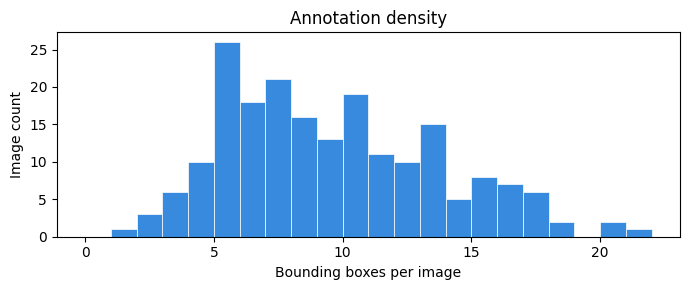

In [23]:
# Count bounding box annotations per image
bbox_counts = []
for _, lbl in paired:
    lines = [l.strip() for l in lbl.read_text().splitlines() if l.strip()]
    bbox_counts.append(len(lines))

if bbox_counts:
    counts = np.array(bbox_counts)
    print(f"Bounding boxes per image:")
    print(f"  Total   : {counts.sum()}")
    print(f"  Min     : {counts.min()}")
    print(f"  Max     : {counts.max()}")
    print(f"  Mean    : {counts.mean():.1f}")
    print(f"  Median  : {np.median(counts):.0f}")
    print()

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(
        counts,
        bins=range(0, int(counts.max()) + 2),
        color="#378ADD",
        edgecolor="white",
        linewidth=0.5)
    ax.set_xlabel("Bounding boxes per image")
    ax.set_ylabel("Image count")
    ax.set_title("Annotation density")
    plt.tight_layout()
    plt.show()
else:
    print("No paired image/label data found — check the verification cell above.")

### Per-split breakdown

In [24]:
# Same summary, but broken down per split (train/val/test) using the manifests
print(f"{'Split':6s} {'Images':>8s} {'Boxes':>8s} {'Avg/img':>9s}")
print("-" * 36)
for split_name in ("train", "val", "test"):
    manifest = SPLITS_DIR / f"{split_name}.txt"
    paths = [p.strip() for p in manifest.read_text().splitlines() if p.strip()]

    split_box_count = 0
    split_img_count = 0
    for p in paths:
        img_path = Path(p)
        if not img_path.is_absolute():
            img_path = DATA_DIR / p
        lbl_path = Path(str(img_path).replace("processed", "labels")).with_suffix(".txt")
        if lbl_path.exists():
            split_img_count += 1
            split_box_count += len([l for l in lbl_path.read_text().splitlines() if l.strip()])

    avg = split_box_count / split_img_count if split_img_count else 0
    print(f"{split_name:6s} {split_img_count:8d} {split_box_count:8d} {avg:9.2f}")

Split    Images    Boxes   Avg/img
------------------------------------
train         0        0      0.00
val           0        0      0.00
test          0        0      0.00


# Section 4 - Dataset preparation

This section makes the **train/val/test split physically usable by `model.train()`**.

We are using the **manifest-based** approach (`train.txt`/`val.txt`/`test.txt`), which `PATCHED_DATASET_YAML` already points to — so no copying of files is required here. This section instead:
1. Confirms `paired` (from Section 3) only contains images that are also listed in one of the three manifests.
2. Surfaces any *labelled* images that are missing from all three manifests (rare, but would silently train on unsplit data if missed).
3. Writes a small `classes.txt` next to the labels, since Label Studio doesn't always export one and Ultralytics doesn't need it — but it's useful for manual review tools.

In [25]:
# Cross-check: every paired (image, label) from Section 3 should appear in
# exactly one of train.txt / val.txt / test.txt — never zero, never more than one.
manifest_paths = {}
for split_name in ("train", "val", "test"):
    manifest = SPLITS_DIR / f"{split_name}.txt"
    listed = {p.strip() for p in manifest.read_text().splitlines() if p.strip()}
    manifest_paths[split_name] = listed

all_listed = set().union(*manifest_paths.values())

# Resolve `paired` image paths to the same string format used in the manifests
paired_relative = set()
for img, _ in paired:
    rel = img.relative_to(DATA_DIR) if img.is_relative_to(DATA_DIR) else img
    paired_relative.add(str(rel))

not_in_any_split = paired_relative - all_listed
in_multiple_splits = [
    p for p in paired_relative
    if sum(p in manifest_paths[s] for s in ("train", "val", "test")) > 1
]

print(f"Labelled images not in any split manifest : {len(not_in_any_split)}")
print(f"Labelled images in more than one manifest  : {len(in_multiple_splits)}")

if not_in_any_split:
    print("\n⚠  These images are paired (have labels) but absent from all manifests —")
    print("   they will be silently excluded from training. Re-run create_splits.py")
    print("   if this list is non-empty after recent annotation work.")
    for p in list(not_in_any_split)[:5]:
        print(f"     {p}")
elif in_multiple_splits:
    print("\n⚠  Data leakage risk — these images appear in more than one split:")
    for p in in_multiple_splits[:5]:
        print(f"     {p}")
else:
    print("\n✓  Every labelled image is assigned to exactly one split.")

Labelled images not in any split manifest : 200
Labelled images in more than one manifest  : 0

⚠  These images are paired (have labels) but absent from all manifests —
   they will be silently excluded from training. Re-run create_splits.py
   if this list is non-empty after recent annotation work.
     processed/video_test_01_f0002295.jpg
     processed/video_test_01_f0002565.jpg
     processed/video_test_01_f0000165.jpg
     processed/video_test_01_f0002805.jpg
     processed/video_test_01_f0000630.jpg


In [26]:
# Not required by Ultralytics (class names already live in
# `PATCHED_DATASET_YAML`), but useful for cross-checking in Label Studio
# or other annotation review tools.

classes_path = LABELS_DIR / "classes.txt"
classes_path.write_text("\n".join(CFG["class_names"]) + "\n")
print(f"Wrote: {classes_path}")
print(open(classes_path).read())

Wrote: /content/project_fruit_detection/data/labels/classes.txt
apple



# Section 5 - Sanity check

Visual inspection of annotated images before training. Verify that:
- Bounding boxes are tight around apples (not loose or offset)
- No boxes are mislabelled or sitting on non-apple objects
- Image quality is representative of the orchard video footage

In [27]:
def draw_yolo_boxes(ax, image_path: Path, label_path: Path, class_names: list) -> None:
    """
    Draw YOLO bounding boxes (normalised xywh) on a matplotlib axis.
    """
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)
    ax.set_title(image_path.name, fontsize=8)
    ax.axis("off")

    for line in label_path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        cls_id, cx, cy, bw, bh = map(float, line.split())
        x1 = (cx - bw / 2) * w
        y1 = (cy - bh / 2) * h
        rect = patches.Rectangle(
            (x1, y1), bw * w, bh * h,
            linewidth=1.5, edgecolor="#00C864", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1,
                y1 - 4,
                class_names[int(cls_id)],
                fontsize=7,
                color="#00C864",
                bbox=dict(facecolor="black", alpha=0.5, pad=1, linewidth=0))

In [ ]:
# Sample randomly from `paired` (Section 3) — works regardless of split,
# since no physical train/val/test folders exist.
samples = random.sample(paired, min(12, len(paired)))

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for ax, (img_path, lbl_path) in zip(axes.flat, samples):
    draw_yolo_boxes(ax, img_path, lbl_path, CFG["class_names"])
for ax in axes.flat[len(samples):]:
    ax.axis("off")

plt.suptitle("Random annotated samples (green = apple)", y=1.01)
plt.tight_layout()
plt.show()

# Section 6 - Training

YOLO11 with transfer learning from COCO pretrained weights.

`RESUME_FROM` lets you continue an interrupted run — useful on Kaggle to stay within GPU quota. Leave it as `None` to start fresh.

In [29]:
# ── Resume flag ───────────────────────────────────────────────────────────────
RESUME_FROM = None
# RESUME_FROM = WORK_DIR / "runs" / CFG["run_name"] / "weights" / "last.pt"

if RESUME_FROM and Path(RESUME_FROM).exists():
    print(f"Resuming from checkpoint: {RESUME_FROM}")
    model = YOLO(str(RESUME_FROM))
    resume = True
else:
    model_weights = f"yolo11{CFG['model_size']}.pt"
    print(f"Starting fresh with: {model_weights}  (downloads COCO pretrained weights)")
    model = YOLO(model_weights)
    resume = False

Starting fresh with: yolo11n.pt  (downloads COCO pretrained weights)


In [34]:
import re

# Robust fix for manifest paths: handle Windows backslashes and redundant 'data' folder prefixes
for split_name in ("train", "val", "test"):
    manifest_path = SPLITS_DIR / f"{split_name}.txt"
    if manifest_path.exists():
        content = manifest_path.read_text()
        # 1. Standardize all slashes to forward slashes
        content = content.replace("\\", "/")
        # 2. Remove 'data/' if it exists at the start of any line
        lines = [re.sub(r'^data/', '', line.strip()) for line in content.splitlines() if line.strip()]
        manifest_path.write_text("\n".join(lines))

results = model.train(
    data       = str(PATCHED_DATASET_YAML),
    epochs     = CFG["epochs"],
    batch      = CFG["batch"],
    imgsz      = CFG["imgsz"],
    patience   = CFG["patience"],

    # Learning rate
    lr0        = CFG["lr0"],
    lrf        = CFG["lrf"],
    warmup_epochs = CFG["warmup_epochs"],
    optimizer  = CFG["optimizer"],
    weight_decay = CFG["weight_decay"],

    # Augmentation
    mosaic     = CFG["mosaic"],
    mixup      = CFG["mixup"],
    fliplr     = CFG["fliplr"],
    flipud     = CFG["flipud"],
    hsv_h      = CFG["hsv_h"],
    hsv_s      = CFG["hsv_s"],
    hsv_v      = CFG["hsv_v"],
    degrees    = CFG["degrees"],
    translate  = CFG["translate"],
    scale      = CFG["scale"],

    # Output
    project    = str(WORK_DIR / CFG["project"]),
    name       = CFG["run_name"],
    save_period= CFG["save_period"],
    workers    = CFG["workers"],
    seed       = CFG["seed"],
    verbose    = CFG["verbose"],
    resume     = resume
)

RUN_DIR = Path(results.save_dir)
print(f"\nTraining complete. Run saved to: {RUN_DIR}")

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/working/dataset.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_v1-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=

RuntimeError: No valid images found in processed.cache.
  [34m[1mtrain: [0mprocessed/video_test_01_f0000000.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: 'processed/video_test_01_f0000000.jpg'
  [34m[1mtrain: [0mprocessed/video_test_01_f0000090.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: 'processed/video_test_01_f0000090.jpg'
  [34m[1mtrain: [0mprocessed/video_test_01_f0000105.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: 'processed/video_test_01_f0000105.jpg'
  [34m[1mtrain: [0mprocessed/video_test_01_f0000120.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: 'processed/video_test_01_f0000120.jpg'
  [34m[1mtrain: [0mprocessed/video_test_01_f0000135.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: 'processed/video_test_01_f0000135.jpg'
  [34m[1mtrain: [0mprocessed/video_test_01_f0000195.jpg: ignoring corrupt image/label: [Errno 2] No such file o

# Section 7 - Training curves

In [ ]:
results_csv = RUN_DIR / "results.csv"
if not results_csv.exists():
    print(f"results.csv not found at {results_csv}")
else:
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()   # Ultralytics CSVs sometimes have leading spaces

    metrics = {
        "Box loss (train)": ("train/box_loss", "#E24B4A"),
        "Box loss (val)"  : ("val/box_loss",   "#378ADD"),
        "mAP50"           : ("metrics/mAP50(B)", "#1D9E75"),
        "mAP50-95"        : ("metrics/mAP50-95(B)", "#7F77DD"),
        "Precision"       : ("metrics/precision(B)", "#EF9F27"),
        "Recall"          : ("metrics/recall(B)",    "#D85A30"),
    }
    available = {k: v for k, v in metrics.items() if v[0] in df.columns}

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, (label, (col, colour)) in zip(axes.flat, available.items()):
        ax.plot(df["epoch"], df[col], color=colour, linewidth=1.5)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3, linewidth=0.5)
    for ax in axes.flat[len(available):]:
        ax.set_visible(False)

    plt.suptitle(f"Training curves — {CFG['run_name']}", y=1.01)
    plt.tight_layout()
    plt.show()

    target_cols = [c for c in ["metrics/precision(B)", "metrics/recall(B)",
                                "metrics/mAP50(B)", "metrics/mAP50-95(B)"] if c in df.columns]
    if target_cols:
        print("\nFinal epoch metrics:")
        last = df[["epoch"] + target_cols].iloc[-1]
        for col, val in last.items():
            print(f"  {col:<35} {val:.4f}")

# Section 8 - Evaluation

Evaluate the best checkpoint against the project's target metrics:

| Metric    | Target  |
|-----------|---------|
| Precision | ≥ 0.80  |
| Recall    | ≥ 0.80  |
| mAP50     | ≥ 0.75  |
| mAP50-95  | ≥ 0.40  |

In [ ]:
TARGET_METRICS = {
    "Precision"  : ("metrics/precision(B)", 0.80),
    "Recall"     : ("metrics/recall(B)",    0.80),
    "mAP50"      : ("metrics/mAP50(B)",     0.75),
    "mAP50-95"   : ("metrics/mAP50-95(B)", 0.40),
}

def run_evaluation(model_path: Path, split: str, label: str) -> dict:
    """Run validation on `split` (using PATCHED_DATASET_YAML) and print a pass/fail report."""
    print(f"\n{'─'*50}")
    print(f"Evaluating: {label}  ({split} split)")
    print(f"Model     : {model_path}")
    print('─'*50)

    eval_model = YOLO(str(model_path))
    metrics = eval_model.val(
        data    = str(PATCHED_DATASET_YAML),
        split   = split,
        imgsz   = CFG["imgsz"],
        batch   = CFG["batch"],
        verbose = False,
    )

    results_dict = {
        "metrics/precision(B)" : metrics.box.mp,
        "metrics/recall(B)"    : metrics.box.mr,
        "metrics/mAP50(B)"     : metrics.box.map50,
        "metrics/mAP50-95(B)"  : metrics.box.map,
    }

    print(f"\n{'Metric':<25} {'Value':>8}   {'Target':>8}   Status")
    print("─" * 60)
    all_pass = True
    for label_, (key, target) in TARGET_METRICS.items():
        val = results_dict.get(key, float("nan"))
        passed = val >= target
        all_pass = all_pass and passed
        status = "✓ PASS" if passed else "✗ FAIL"
        print(f"  {label_:<23} {val:>8.4f}   {target:>8.2f}   {status}")

    print("─" * 60)
    print("Overall:", "✓ ALL PASS" if all_pass else "✗ NOT YET — keep training or add more data")
    return results_dict

In [ ]:
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"

val_results  = run_evaluation(BEST_WEIGHTS, split="val",  label="Validation set")
test_results = run_evaluation(BEST_WEIGHTS, split="test", label="Test set")

# Section 9 - Prediction samples

In [ ]:
pred_model = YOLO(str(BEST_WEIGHTS))

# Read val.txt manifest directly — these are the held-out images
val_manifest = SPLITS_DIR / "val.txt"
val_paths = [DATA_DIR / p.strip() for p in val_manifest.read_text().splitlines() if p.strip()]
val_paths = [p for p in val_paths if p.exists()]

samples = random.sample(val_paths, min(8, len(val_paths)))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, img_path in zip(axes.flat, samples):
    result  = pred_model.predict(str(img_path), conf=0.25, iou=0.45, verbose=False)[0]
    plotted = result.plot(line_width=2, font_size=8)   # returns BGR numpy array
    ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{len(result.boxes)} detections", fontsize=8)
    ax.axis("off")
for ax in axes.flat[len(samples):]:
    ax.axis("off")

plt.suptitle("Validation set — model predictions", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Confidence distribution across all validation images
all_confs = []
for img_path in val_paths:
    res = pred_model.predict(str(img_path), conf=0.10, iou=0.45, verbose=False)[0]
    all_confs.extend(res.boxes.conf.cpu().numpy().tolist())

if all_confs:
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(all_confs, bins=30, range=(0.1, 1.0), color="#378ADD", edgecolor="white", linewidth=0.5)
    ax.axvline(0.25, color="#E24B4A", linestyle="--", linewidth=1, label="Default threshold (0.25)")
    ax.set_xlabel("Confidence score")
    ax.set_ylabel("Detection count")
    ax.set_title("Detection confidence distribution — validation set")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Total detections (conf > 0.10): {len(all_confs)}")
    print(f"Mean confidence              : {np.mean(all_confs):.3f}")
else:
    print("No detections found — model may need more training or a lower threshold.")

# Section 10 - Export weights and metrics

Save the best weights and a metrics summary to `WORK_DIR` (keeps `RAW_DATASET_DIR` untouched, per the read-only convention from Section 2).

On Kaggle, anything under `WORK_DIR` (`/kaggle/working/`) is downloadable once the run finishes.

In [ ]:
EXPORT_DIR = WORK_DIR / "exported"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
exported_weights = EXPORT_DIR / f"best_{CFG['run_name']}_{timestamp}.pt"
shutil.copy2(BEST_WEIGHTS, exported_weights)
print(f"Weights exported: {exported_weights}")

summary = {
    "run_name"      : CFG["run_name"],
    "model"         : f"yolo11{CFG['model_size']}",
    "epochs_trained": int(df["epoch"].max()) if "df" in dir() else "unknown",
    "timestamp"     : timestamp,
    "config"        : CFG,
    "val_metrics"   : {k.split("/")[-1].replace("(B)", ""): round(v, 4)
                       for k, v in val_results.items()},
    "test_metrics"  : {k.split("/")[-1].replace("(B)", ""): round(v, 4)
                       for k, v in test_results.items()},
}

metrics_path = EXPORT_DIR / f"metrics_{CFG['run_name']}_{timestamp}.json"
with open(metrics_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Metrics saved  : {metrics_path}")

print("\n── Summary ──────────────────────────────────────────────────")
print(f"  Model  : {summary['model']}")
print(f"  Run    : {summary['run_name']}")
print("  Validation metrics:")
for k, v in summary["val_metrics"].items():
    print(f"    {k:<20} {v}")